### Introduction

Sentiment analysis is a Natural Language Processing (NLP) technique used to determine the emotional tone behind textual data. It is widely applied in analyzing customer reviews, social media posts, and online feedback to classify opinions as positive, negative, or neutral. This approach helps organizations understand how customers perceive their products or services.

In this task, sentiment analysis is performed on Amazon product reviews to evaluate customer opinions and identify underlying sentiment patterns. The analysis involves preprocessing textual data, applying the VADER (Valence Aware Dictionary and sEntiment Reasoner) model to compute sentiment scores, and classifying the reviews into sentiment categories.

Additionally, emotion detection techniques are used to identify specific feelings expressed in the reviews, such as joy, anger, or sadness. The results of this analysis provide valuable insights into customer satisfaction and can support data-driven decisions in marketing, product development, and customer experience management.

### Data Source

The dataset used in this task consists of Amazon product reviews obtained from Kaggle. It contains textual reviews along with associated ratings, which makes it suitable for sentiment analysis. The "Text" column was used as the primary feature for analyzing customer opinions.

A subset of 5000 reviews was sampled from the dataset to improve computational efficiency while maintaining a representative distribution of sentiments.

In [1]:
import pandas as pd

df = pd.read_csv("Reviews.csv")
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [2]:
df.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')

In [3]:
# Reducimg dataset size
df = df.sample(5000, random_state=42)

In [4]:
# Handling missing values
df = df.dropna(subset={'Text'})

In [5]:
# Cleaning text
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z ]", "", text)
    return text

df['cleaned_text'] = df['Text'].apply(clean_text)
df[['Text', 'cleaned_text']].head()

,Text,cleaned_text
165256,Having tried a couple of other brands of glute...,having tried a couple of other brands of glute...
231465,My cat loves these treats. If ever I can't fin...,my cat loves these treats if ever i cant find ...
427827,A little less than I expected. It tends to ha...,a little less than i expected it tends to hav...
433954,"First there was Frosted Mini-Wheats, in origin...",first there was frosted miniwheats in original...
70260,and I want to congratulate the graphic artist ...,and i want to congratulate the graphic artist ...


Text preprocessing involved converting text to lowercase, removing punctuation, special characters, and URLs to standardize the data and improve sentiment analysis accuracy.

In [6]:
# Applying Sentiment Analysis
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

df['score'] = df[ 'cleaned_text'].apply(lambda x: sia.polarity_scores(x)['compound'])

[nltk_data] Downloading package vader_lexicon to C:\Users\MOIPO
[nltk_data]     NE\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [7]:
df[['cleaned_text', 'score']].head()

,cleaned_text,score
165256,having tried a couple of other brands of glute...,0.9672
231465,my cat loves these treats if ever i cant find ...,0.7739
427827,a little less than i expected it tends to hav...,0.4588
433954,first there was frosted miniwheats in original...,0.9923
70260,and i want to congratulate the graphic artist ...,0.9629


###  Technical Interpretation of VADER Results
The `score` column represents the **Compound Score**, which is a metric that calculates the sum of all lexicon ratings, normalized between -1 (most negative) and +1 (most positive).

* **Positive Sentiment:** Reviews scoring above 0.05 indicate favorable language.
* **Neutral Sentiment:** Scores near 0.00 suggest the text is purely functional or lacks emotional descriptors.
* **Accuracy Check:** By comparing the `score` to the original `Score` (1-5 stars) seen in the raw data, we can validate if the NLP model is correctly detecting dissatisfaction in 1-star reviews

In [8]:
def classify_sentiment(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df['sentiment'] = df['score'].apply(classify_sentiment)

In [9]:
df['sentiment'].value_counts()

sentiment
Positive    4373
Negative     524
Neutral      103
Name: count, dtype: int64

### Interpretation

The sentiment analysis results show that the majority of reviews (approximately 87%) are positive, indicating a high level of customer satisfaction. Negative reviews account for about 10%, while neutral reviews are minimal at around 2%. This suggests that customers generally have a favorable perception of the product.

### Insight 1:
The high proportion of positive reviews suggests that the product meets or exceeds customer expectations.

### Insight 2:
Although negative reviews are fewer, they are still significant and may highlight specific issues that need attention.

### Insight 3:
The low number of neutral reviews indicates that customers tend to have strong opinions rather than moderate or indifferent views.

### Business Application of Sentiment Analysis

The results of the sentiment analysis provide valuable insights for business decision-making. The high proportion of positive reviews (87%) indicates strong customer satisfaction, which can be leveraged in marketing campaigns to attract new customers and build brand trust.

Negative reviews, although fewer in number, highlight potential areas for improvement. By analyzing these reviews, businesses can identify common issues such as product quality or delivery concerns and take corrective action.

Additionally, sentiment analysis enables companies to continuously monitor customer opinions and adapt their strategies based on real-time feedback, improving overall customer experience.

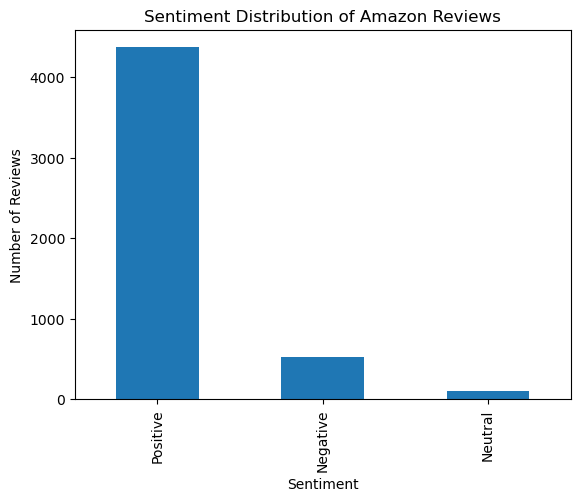

In [10]:
import matplotlib.pyplot as plt

df['sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution of Amazon Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

### Interpretation

The bar chart illustrates that positive sentiment dominates the dataset, with significantly fewer negative and neutral reviews. This confirms that customer feedback is largely favorable.

In [11]:
pd.crosstab(df['Score'], df['sentiment'])

sentiment,Negative,Neutral,Positive
Score,,,
1,212,26,217
2,73,14,161
3,75,13,290
4,37,16,648
5,127,34,3057


There is a strong relationship between star ratings and sentiment classification, where higher ratings correspond to positive sentiment and lower ratings correspond to negative sentiment.

### Conclusion

This task demonstrated how sentiment analysis can be applied to real-world textual data to understand customer opinions. Using Amazon product reviews, the VADER model was used to classify sentiments as positive, negative, or neutral based on computed sentiment scores.

The results showed that the majority of reviews were positive, indicating a high level of customer satisfaction, while a smaller proportion of negative and neutral reviews highlighted areas that may require improvement. These findings illustrate how sentiment analysis can uncover patterns in customer feedback and provide meaningful insights.

Overall, this analysis highlights the value of Natural Language Processing techniques in supporting data-driven decision-making. Businesses can use such insights to improve products, enhance customer experience, and develop more effective marketing strategies.